# ACV-VLAD v2: Leak-Safe Classical Vision Notebook

This notebook replaces the earlier ORB+BoVW workflow with a stronger non-neural ensemble centered on:

- dense RootSIFT descriptors on controlled upscaled images,
- spatial VLAD encoding with fold-local fitting,
- compact handcrafted low-resolution features,
- 5-fold out-of-fold evaluation and stacking,
- optional pseudo-labeling for a single final transductive pass.

The main design goal is Kaggle-style accuracy with disciplined validation. Test labels in `test.csv` are treated as placeholders and are never used for tuning.


## Notebook Roadmap

1. setup and dependency bootstrap,
2. configuration and reproducibility,
3. dataset audit and visual inspection,
4. global handcrafted feature extraction,
5. dense RootSIFT descriptor extraction,
6. fold-safe VLAD fitting and feature fusion,
7. base-model OOF evaluation,
8. stacked generalization,
9. optional pseudo-labeling,
10. final full-train inference and `submission.csv` export.

The notebook keeps raw per-image caches only. Every learned transform is fit inside the current fold.


In [1]:
# If your notebook runtime is missing any dependency, this cell installs only what is needed.
from __future__ import annotations

import importlib.util
import os
import subprocess
import sys
import warnings

os.environ.setdefault("JOBLIB_TEMP_FOLDER", os.path.join("cache", "joblib_temp"))
os.makedirs(os.environ["JOBLIB_TEMP_FOLDER"], exist_ok=True)

REQUIRED_MODULES = {
    "numpy": "numpy>=1.24,<2.0",
    "pandas": "pandas>=2.0",
    "sklearn": "scikit-learn>=1.3",
    "skimage": "scikit-image>=0.21",
    "matplotlib": "matplotlib>=3.7",
    "seaborn": "seaborn>=0.12",
    "PIL": "Pillow>=10.0",
    "joblib": "joblib>=1.3",
    "tqdm": "tqdm>=4.65",
    "xgboost": "xgboost>=2.0",
    "catboost": "catboost>=1.2",
    "cv2": "opencv-contrib-python-headless>=4.9",
}
OPTIONAL_MODULES = {
    "umap": "umap-learn>=0.5",
}

missing = [pkg for module, pkg in REQUIRED_MODULES.items() if importlib.util.find_spec(module) is None]
if missing:
    print("Installing missing packages:", missing)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
else:
    print("Core dependencies already available")

try:
    if importlib.util.find_spec("cuml.accel") is not None:
        get_ipython().run_line_magic("load_ext", "cuml.accel")
        print("cuml.accel enabled")
    else:
        print("cuml.accel not available; using standard sklearn implementations")
except Exception as exc:
    print(f"cuml.accel could not be enabled: {exc}")

try:
    import sklearnex
    sklearnex.patch_sklearn()
    print("sklearnex acceleration enabled")
except Exception as exc:
    print(f"sklearnex not enabled: {exc}")

import gc
import hashlib
import json
import math
import random
import time
from pathlib import Path

import cv2
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from catboost import CatBoostClassifier
from IPython.display import Markdown, display
from joblib import Parallel, delayed
from PIL import Image
from skimage.color import rgb2gray, rgb2hsv, rgb2lab
from skimage.feature import hog, local_binary_pattern
from sklearn.cluster import MiniBatchKMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from threadpoolctl import threadpool_limits
from tqdm.auto import tqdm
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

try:
    import umap
except Exception:
    umap = None


Core dependencies already available
cuml.accel could not be enabled: No module named 'cuml'


Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)


sklearnex acceleration enabled


f:\Conda\envs\COMP3314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
DATA_DIR = Path("data")
TRAIN_DIR = DATA_DIR / "train_ims"
TEST_DIR = DATA_DIR / "test_ims"
TRAIN_CSV = DATA_DIR / "train.csv"
TEST_CSV = DATA_DIR / "test.csv"

CACHE_DIR = Path("cache")
CACHE_DIR.mkdir(exist_ok=True)
GLOBAL_CACHE_DIR = CACHE_DIR / "global_features"
DESC_CACHE_DIR = CACHE_DIR / "dense_rootsift"
GLOBAL_CACHE_DIR.mkdir(exist_ok=True)
DESC_CACHE_DIR.mkdir(exist_ok=True)

IMAGE_COL = "im_name"
LABEL_COL = "label"
SEED = 42
SMOKE_MODE = False
TRAIN_SAMPLE_LIMIT = 6_000 if SMOKE_MODE else None
N_FOLDS = 5
USE_GPU = True
ENABLE_UMAP = False
ENABLE_PSEUDO_LABEL = False
ENABLE_TTA = True

UPSCALE_SIZE = 96
DENSE_STEPS = (6,)
DENSE_SIZES = (12, 18)
LOCAL_PCA_DIM = 64
VLAD_CLUSTERS = 64
VLAD_SPATIAL_GRIDS = ((1, 1), (2, 1), (3, 3))
GLOBAL_PCA_DIM = 256
FUSED_PCA_DIM = 512
VLAD_PCA_FIT_SAMPLES = 4096
VLAD_ENCODE_BATCH_SIZE = 256
PSEUDO_THRESHOLD = 0.995
PSEUDO_MAX_PER_CLASS = 250

RGB_HIST_BINS = 16
LAB_HIST_BINS = (8, 8, 8)
LBP_BINS = np.arange(0, 11)
MAX_DESCRIPTORS_PER_IMAGE = 256
MAX_CODEBOOK_DESCRIPTORS = 400_000
FEATURE_N_JOBS = max(1, min(8, (os.cpu_count() or 4) // 2))
MODEL_N_JOBS = max(1, min(16, (os.cpu_count() or 4) - 1))
N_JOBS = FEATURE_N_JOBS
CACHE_VERSION = "acv_vlad_v2"

RESAMPLE_BICUBIC = getattr(getattr(Image, "Resampling", Image), "BICUBIC")


def seed_everything(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)


def make_training_subset(df: pd.DataFrame, sample_limit: int | None) -> pd.DataFrame:
    if sample_limit is None or sample_limit >= len(df):
        return df.copy().reset_index(drop=True)

    sampled_df, _ = train_test_split(
        df,
        train_size=sample_limit,
        stratify=df[LABEL_COL],
        random_state=SEED,
    )
    return sampled_df.sort_values(IMAGE_COL).reset_index(drop=True)


def load_rgb_image(image_path: Path) -> np.ndarray:
    with Image.open(image_path) as image:
        return np.asarray(image.convert("RGB"), dtype=np.uint8)


seed_everything(SEED)
print(
    f"FEATURE_N_JOBS={FEATURE_N_JOBS}, MODEL_N_JOBS={MODEL_N_JOBS}, "
    f"USE_GPU={USE_GPU}, ENABLE_UMAP={ENABLE_UMAP}, ENABLE_PSEUDO_LABEL={ENABLE_PSEUDO_LABEL}"
)


N_JOBS=23, USE_GPU=True, ENABLE_UMAP=False, ENABLE_PSEUDO_LABEL=False


In [3]:
train_df_full = pd.read_csv(TRAIN_CSV)
test_df_raw = pd.read_csv(TEST_CSV)
test_df = test_df_raw[[IMAGE_COL]].copy()
test_df[LABEL_COL] = 0
train_df = make_training_subset(train_df_full, TRAIN_SAMPLE_LIMIT)

print(f"Training rows used in this run: {len(train_df):,}")
print(f"Full training rows available:   {len(train_df_full):,}")
print(f"Test rows:                      {len(test_df):,}")
print(f"Number of classes:              {train_df_full[LABEL_COL].nunique()}")
print("Note: test.csv labels are placeholders and are ignored by the pipeline.")

class_counts = train_df_full[LABEL_COL].value_counts().sort_index()
summary_df = pd.DataFrame({"Class": class_counts.index, "Count": class_counts.values})
display(summary_df)

run_note = "Smoke mode is active on a stratified subset." if TRAIN_SAMPLE_LIMIT is not None else "Full-train mode is active."
display(Markdown(f"**Run mode:** {run_note}"))


Training rows used in this run: 50,000
Full training rows available:   50,000
Test rows:                      10,000
Number of classes:              10
Note: test.csv labels are placeholders and are ignored by the pipeline.


,Class,Count
0,0,5027
1,1,5008
2,2,5026
3,3,4946
4,4,5061
5,5,5005
6,6,4962
7,7,5006
8,8,5012
9,9,4947


**Run mode:** Full-train mode is active.

## Dataset Audit

This challenge is visually close to CIFAR-style classification: tiny `32x32` images, meaningful color priors, and weak fine-grained detail.
That makes two complementary branches useful:

- a compact handcrafted branch for color and coarse edge statistics,
- a dense descriptor branch that aggregates local gradients with VLAD rather than counting visual words.


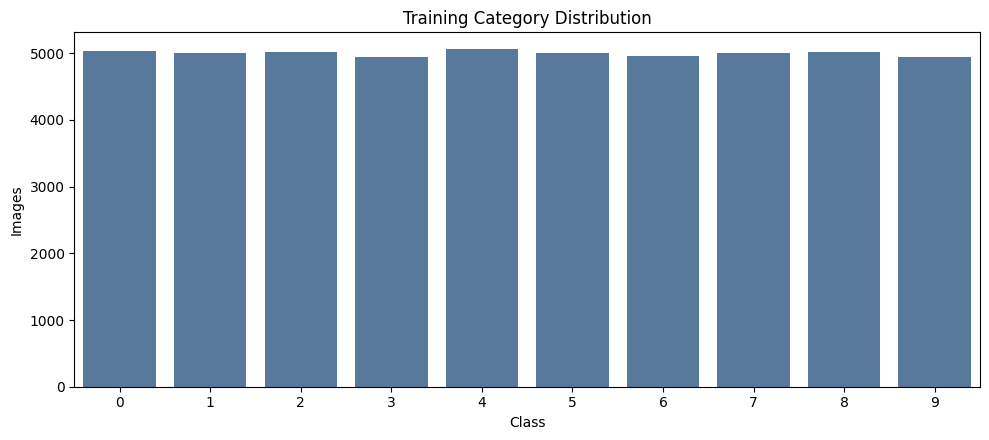

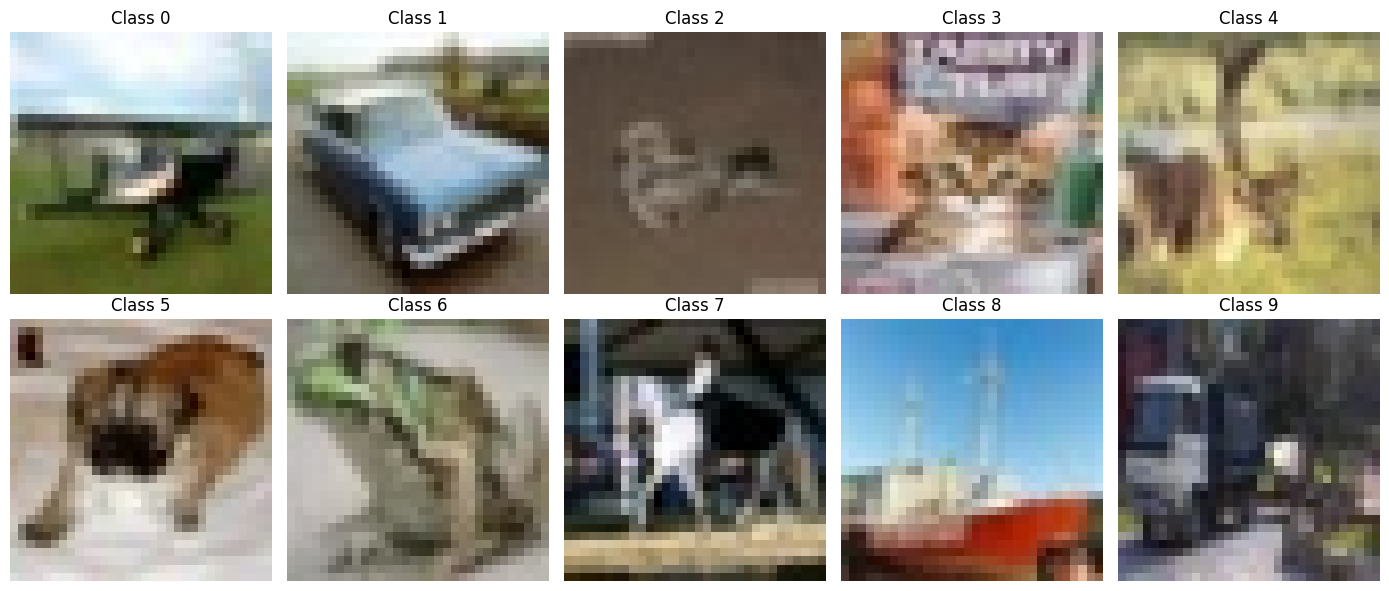

In [4]:
fig, ax = plt.subplots(figsize=(10, 4.5))
sns.barplot(data=summary_df, x="Class", y="Count", ax=ax, color="#4e79a7")
ax.set_title("Training Category Distribution")
ax.set_ylabel("Images")
fig.tight_layout()
fig.savefig("01_category_distribution.png", dpi=180)
plt.show()

example_df = (
    train_df_full.groupby(LABEL_COL, group_keys=False)
    .head(1)
    .sort_values(LABEL_COL)
    .reset_index(drop=True)
)

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for ax, row in zip(axes.flat, example_df.to_dict("records")):
    image = load_rgb_image(TRAIN_DIR / row[IMAGE_COL])
    ax.imshow(image)
    ax.set_title(f"Class {row[LABEL_COL]}")
    ax.axis("off")
fig.tight_layout()
fig.savefig("02_sample_images_per_category.png", dpi=180)
plt.show()


## 1. Global Handcrafted Branch

The handcrafted branch keeps the strongest low-resolution signals from the original notebook:

- HOG for coarse edge structure,
- uniform LBP for texture,
- RGB histograms and LAB histograms for color distribution,
- HSV and RGB moments for scene-level statistics.

These features are cheap, stable, and especially useful on tiny images where global priors matter.


In [5]:
def extract_lab_histogram(image: np.ndarray, bins: tuple[int, int, int] = LAB_HIST_BINS) -> np.ndarray:
    arr = image.astype(np.float32) / 255.0
    lab = rgb2lab(arr)
    l_channel = np.clip(lab[:, :, 0] / 100.0, 0.0, 1.0)
    a_channel = np.clip((lab[:, :, 1] + 128.0) / 255.0, 0.0, 1.0)
    b_channel = np.clip((lab[:, :, 2] + 128.0) / 255.0, 0.0, 1.0)

    hist, _ = np.histogramdd(
        np.stack([l_channel, a_channel, b_channel], axis=-1).reshape(-1, 3),
        bins=bins,
        range=((0.0, 1.0), (0.0, 1.0), (0.0, 1.0)),
    )
    hist = hist.astype(np.float32)
    if hist.sum() > 0:
        hist /= hist.sum()
    return hist.reshape(-1)


def extract_global_groups(image: np.ndarray) -> dict[str, np.ndarray]:
    arr = image.astype(np.float32) / 255.0
    gray = rgb2gray(arr)
    hsv = rgb2hsv(arr)

    hog_features = hog(
        gray,
        orientations=9,
        pixels_per_cell=(4, 4),
        cells_per_block=(2, 2),
        block_norm="L2-Hys",
        feature_vector=True,
    ).astype(np.float32)

    lbp_map = local_binary_pattern((gray * 255).astype(np.uint8), P=8, R=1, method="uniform")
    lbp_hist, _ = np.histogram(
        lbp_map.ravel(),
        bins=LBP_BINS,
        range=(0, 10),
        density=True,
    )
    lbp_hist = lbp_hist.astype(np.float32)

    rgb_hist_parts = []
    for channel in range(3):
        hist, _ = np.histogram(
            arr[:, :, channel],
            bins=RGB_HIST_BINS,
            range=(0.0, 1.0),
            density=True,
        )
        rgb_hist_parts.append(hist.astype(np.float32))
    rgb_hist = np.concatenate(rgb_hist_parts).astype(np.float32)

    color_stats = np.concatenate(
        [
            rgb_hist,
            hsv.mean(axis=(0, 1)),
            hsv.std(axis=(0, 1)),
            arr.mean(axis=(0, 1)),
            arr.std(axis=(0, 1)),
        ]
    ).astype(np.float32)

    return {
        "hog_lbp": np.concatenate([hog_features, lbp_hist]).astype(np.float32),
        "color_stats": color_stats,
        "lab_hist": extract_lab_histogram(image),
    }


def extract_global_payload(
    df: pd.DataFrame,
    image_dir: Path,
    cache_stem: str,
    *,
    flip: bool = False,
    use_cache: bool = True,
) -> dict[str, np.ndarray]:
    suffix = "flip" if flip else "orig"
    cache_path = GLOBAL_CACHE_DIR / f"{cache_stem}_{CACHE_VERSION}_{suffix}.joblib"
    image_names = df[IMAGE_COL].tolist()

    if use_cache and cache_path.exists():
        payload = joblib.load(cache_path)
        if payload[IMAGE_COL].tolist() == image_names:
            print(f"Loaded cached global payload from {cache_path}")
            return {key: payload[key].astype(np.float32) for key in payload if key != IMAGE_COL}

    def _extract_one(image_name: str) -> dict[str, np.ndarray]:
        image = load_rgb_image(image_dir / image_name)
        if flip:
            image = np.fliplr(image)
        return extract_global_groups(image)

    start = time.time()
    with threadpool_limits(limits=1):
        rows = Parallel(n_jobs=FEATURE_N_JOBS, prefer="threads")(
            delayed(_extract_one)(image_name) for image_name in image_names
        )
    elapsed = time.time() - start

    group_names = rows[0].keys()
    payload = {group: np.vstack([row[group] for row in rows]).astype(np.float32) for group in group_names}
    payload[IMAGE_COL] = np.array(image_names)
    joblib.dump(payload, cache_path, compress=3)
    print(f"Extracted global payload for {len(image_names):,} images ({suffix}) in {elapsed:.1f}s")
    return {key: payload[key].astype(np.float32) for key in payload if key != IMAGE_COL}


def build_global_matrix(payload: dict[str, np.ndarray]) -> np.ndarray:
    return np.hstack([payload["hog_lbp"], payload["color_stats"], payload["lab_hist"]]).astype(np.float32)


In [6]:
train_global_orig = extract_global_payload(train_df, TRAIN_DIR, cache_stem=f"train_{len(train_df)}", flip=False)
train_global_flip = extract_global_payload(train_df, TRAIN_DIR, cache_stem=f"train_{len(train_df)}", flip=True)
test_global_orig = extract_global_payload(test_df, TEST_DIR, cache_stem=f"test_{len(test_df)}", flip=False)
test_global_flip = extract_global_payload(test_df, TEST_DIR, cache_stem=f"test_{len(test_df)}", flip=True)

train_global_matrix_orig = build_global_matrix(train_global_orig)
train_global_matrix_flip = build_global_matrix(train_global_flip)
test_global_matrix_orig = build_global_matrix(test_global_orig)
test_global_matrix_flip = build_global_matrix(test_global_flip)

print("Global matrix shapes:")
print("  train/orig:", train_global_matrix_orig.shape)
print("  train/flip:", train_global_matrix_flip.shape)
print("  test/orig: ", test_global_matrix_orig.shape)
print("  test/flip: ", test_global_matrix_flip.shape)


Loaded cached global payload from cache\global_features\train_50000_acv_vlad_v2_orig.joblib
Loaded cached global payload from cache\global_features\train_50000_acv_vlad_v2_flip.joblib
Loaded cached global payload from cache\global_features\test_10000_acv_vlad_v2_orig.joblib
Loaded cached global payload from cache\global_features\test_10000_acv_vlad_v2_flip.joblib
Global matrix shapes:
  train/orig: (50000, 2346)
  train/flip: (50000, 2346)
  test/orig:  (10000, 2346)
  test/flip:  (10000, 2346)


## 2. Dense RootSIFT Descriptor Branch

Sparse keypoints are replaced by dense SIFT on a controlled `96x96` upscaled image. We then apply RootSIFT to make the descriptors more robust before VLAD fitting.

To keep the cache tractable on `50k` training images, descriptors are stored as `float16` payloads and capped per image after deterministic dense extraction.


In [7]:
if not hasattr(cv2, "SIFT_create"):
    raise RuntimeError("OpenCV SIFT is unavailable. Install opencv-contrib-python-headless in the notebook runtime.")


def prepare_descriptor_image(image: np.ndarray, target_size: int = UPSCALE_SIZE) -> np.ndarray:
    pil_image = Image.fromarray(image)
    resized = pil_image.resize((target_size, target_size), RESAMPLE_BICUBIC)
    return np.asarray(resized, dtype=np.uint8)


def build_dense_keypoints(height: int, width: int) -> list:
    keypoints = []
    for step in DENSE_STEPS:
        for size in DENSE_SIZES:
            radius = max(int(round(size / 2)), 1)
            ys = list(range(radius, max(radius + 1, height - radius + 1), step))
            xs = list(range(radius, max(radius + 1, width - radius + 1), step))
            if not ys:
                ys = [height / 2.0]
            if not xs:
                xs = [width / 2.0]
            for y in ys:
                for x in xs:
                    keypoints.append(cv2.KeyPoint(float(x), float(y), float(size)))
    return keypoints


def rootsift_transform(descriptors: np.ndarray | None) -> np.ndarray:
    if descriptors is None or len(descriptors) == 0:
        return np.empty((0, 128), dtype=np.float32)
    desc = descriptors.astype(np.float32)
    desc /= np.maximum(desc.sum(axis=1, keepdims=True), 1e-12)
    desc = np.sqrt(desc).astype(np.float32)
    return desc


def limit_descriptors(points: np.ndarray, descriptors: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    if MAX_DESCRIPTORS_PER_IMAGE is None or len(descriptors) <= MAX_DESCRIPTORS_PER_IMAGE:
        return points.astype(np.float32), descriptors.astype(np.float32)

    index = np.linspace(0, len(descriptors) - 1, MAX_DESCRIPTORS_PER_IMAGE, dtype=int)
    index = np.unique(index)
    return points[index].astype(np.float32), descriptors[index].astype(np.float32)


def extract_dense_descriptor_entry(image: np.ndarray) -> dict[str, np.ndarray]:
    descriptor_image = prepare_descriptor_image(image)
    gray = cv2.cvtColor(descriptor_image, cv2.COLOR_RGB2GRAY)
    sift = cv2.SIFT_create()
    keypoints = build_dense_keypoints(gray.shape[0], gray.shape[1])
    keypoints, descriptors = sift.compute(gray, keypoints)
    descriptors = rootsift_transform(descriptors)

    if keypoints is None or len(descriptors) == 0:
        return {
            "points": np.empty((0, 2), dtype=np.float32),
            "descriptors": np.empty((0, 128), dtype=np.float16),
            "shape": np.asarray(gray.shape, dtype=np.int16),
        }

    points = np.asarray([kp.pt for kp in keypoints], dtype=np.float32)
    points, descriptors = limit_descriptors(points, descriptors)
    return {
        "points": points.astype(np.float32),
        "descriptors": descriptors.astype(np.float16),
        "shape": np.asarray(gray.shape, dtype=np.int16),
    }


def extract_descriptor_entries(
    df: pd.DataFrame,
    image_dir: Path,
    cache_stem: str,
    *,
    flip: bool = False,
    use_cache: bool = True,
) -> list[dict[str, np.ndarray]]:
    suffix = "flip" if flip else "orig"
    cache_path = DESC_CACHE_DIR / f"{cache_stem}_{CACHE_VERSION}_96px_sift_{suffix}.joblib"
    image_names = df[IMAGE_COL].tolist()

    if use_cache and cache_path.exists():
        payload = joblib.load(cache_path)
        if payload[IMAGE_COL].tolist() == image_names:
            entries = payload["entries"]
            print(f"Loaded cached descriptor entries from {cache_path}")
            return entries

    def _extract_one(image_name: str) -> dict[str, np.ndarray]:
        image = load_rgb_image(image_dir / image_name)
        if flip:
            image = np.fliplr(image)
        return extract_dense_descriptor_entry(image)

    start = time.time()
    entries = Parallel(n_jobs=FEATURE_N_JOBS, backend="loky")(
        delayed(_extract_one)(image_name) for image_name in image_names
    )
    elapsed = time.time() - start
    nonempty = sum(len(entry["descriptors"]) > 0 for entry in entries)
    payload = {IMAGE_COL: np.array(image_names), "entries": entries}
    joblib.dump(payload, cache_path, compress=3)
    print(
        f"Extracted dense RootSIFT payload for {len(entries):,} images ({suffix}) in {elapsed:.1f}s "
        f"with {nonempty:,}/{len(entries):,} non-empty entries"
    )
    return entries


In [8]:
train_desc_orig = extract_descriptor_entries(train_df, TRAIN_DIR, cache_stem=f"train_{len(train_df)}", flip=False)
train_desc_flip = extract_descriptor_entries(train_df, TRAIN_DIR, cache_stem=f"train_{len(train_df)}", flip=True)
test_desc_orig = extract_descriptor_entries(test_df, TEST_DIR, cache_stem=f"test_{len(test_df)}", flip=False)
test_desc_flip = extract_descriptor_entries(test_df, TEST_DIR, cache_stem=f"test_{len(test_df)}", flip=True)

descriptor_counts = np.array([len(entry["descriptors"]) for entry in train_desc_orig], dtype=np.int32)
print(f"Median dense descriptors per image: {np.median(descriptor_counts):.1f}")
print(f"Mean dense descriptors per image:   {descriptor_counts.mean():.1f}")
print(f"Max dense descriptors per image:    {descriptor_counts.max()}")


Loaded cached descriptor entries from cache\dense_rootsift\train_50000_acv_vlad_v2_96px_sift_orig.joblib
Loaded cached descriptor entries from cache\dense_rootsift\train_50000_acv_vlad_v2_96px_sift_flip.joblib
Loaded cached descriptor entries from cache\dense_rootsift\test_10000_acv_vlad_v2_96px_sift_orig.joblib
Loaded cached descriptor entries from cache\dense_rootsift\test_10000_acv_vlad_v2_96px_sift_flip.joblib
Median dense descriptors per image: 256.0
Mean dense descriptors per image:   256.0
Max dense descriptors per image:    256


## 3. Fold-Safe VLAD Encoder And Model Utilities

The key leak-safety rule is simple: the following objects are fit only on the current fold's training rows:

- global branch scaler and PCA,
- local descriptor PCA,
- VLAD codebook,
- VLAD PCA,
- optional UMAP,
- stacking scaler and meta-learner.


In [9]:
def subset_entries(entries: list[dict[str, np.ndarray]], indices: np.ndarray) -> list[dict[str, np.ndarray]]:
    return [entries[int(idx)] for idx in indices]


def metric_row(y_true: np.ndarray, y_pred: np.ndarray) -> dict[str, float]:
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro Precision": precision_score(y_true, y_pred, average="macro"),
        "Macro Recall": recall_score(y_true, y_pred, average="macro"),
        "Macro F1": f1_score(y_true, y_pred, average="macro"),
    }


def ensure_2d_scores(scores: np.ndarray, n_classes: int) -> np.ndarray:
    scores = np.asarray(scores)
    if scores.ndim == 1:
        scores = np.stack([-scores, scores], axis=1)
    if scores.shape[1] != n_classes:
        raise ValueError(f"Expected {n_classes} score columns, got {scores.shape[1]}")
    return scores.astype(np.float32)


def scores_to_predictions(scores: np.ndarray) -> np.ndarray:
    return np.argmax(scores, axis=1).astype(int)


def scores_to_probabilities(scores: np.ndarray) -> np.ndarray:
    if np.all(scores >= 0.0):
        row_sums = scores.sum(axis=1, keepdims=True)
        if np.allclose(row_sums, 1.0, atol=1e-4):
            return scores.astype(np.float32)
    shifted = scores - scores.max(axis=1, keepdims=True)
    exp_scores = np.exp(shifted)
    return (exp_scores / np.maximum(exp_scores.sum(axis=1, keepdims=True), 1e-12)).astype(np.float32)


def sample_training_descriptors(entries: list[dict[str, np.ndarray]]) -> np.ndarray:
    nonempty = [entry for entry in entries if len(entry["descriptors"]) > 0]
    if not nonempty:
        raise RuntimeError("No descriptors available for VLAD training.")

    per_image_budget = max(1, MAX_CODEBOOK_DESCRIPTORS // len(nonempty))
    rng = np.random.default_rng(SEED)
    sampled = []
    for entry in nonempty:
        desc = entry["descriptors"].astype(np.float32)
        if len(desc) > per_image_budget:
            sample_idx = rng.choice(len(desc), size=per_image_budget, replace=False)
            desc = desc[sample_idx]
        sampled.append(desc)

    descriptors = np.vstack(sampled).astype(np.float32)
    if len(descriptors) > MAX_CODEBOOK_DESCRIPTORS:
        sample_idx = rng.choice(len(descriptors), size=MAX_CODEBOOK_DESCRIPTORS, replace=False)
        descriptors = descriptors[sample_idx]
    return descriptors.astype(np.float32)


def fit_global_branch(X_train_orig: np.ndarray, X_train_flip: np.ndarray) -> tuple[StandardScaler, PCA | None]:
    scaler = StandardScaler()
    X_stack = np.vstack([X_train_orig, X_train_flip]).astype(np.float32)
    X_scaled = scaler.fit_transform(X_stack).astype(np.float32)
    n_components = min(GLOBAL_PCA_DIM, X_scaled.shape[0] - 1, X_scaled.shape[1])
    if n_components >= 2:
        pca = PCA(n_components=n_components, svd_solver="randomized", random_state=SEED)
        pca.fit(X_scaled)
    else:
        pca = None
    return scaler, pca


def transform_global_branch(X_raw: np.ndarray, scaler: StandardScaler, pca: PCA | None) -> np.ndarray:
    X_scaled = scaler.transform(X_raw).astype(np.float32)
    if pca is not None:
        return pca.transform(X_scaled).astype(np.float32)
    return X_scaled.astype(np.float32)


def fit_vlad_encoder(entries_train_orig: list[dict[str, np.ndarray]]) -> tuple[PCA, MiniBatchKMeans]:
    sampled_descriptors = sample_training_descriptors(entries_train_orig)
    n_local = min(LOCAL_PCA_DIM, sampled_descriptors.shape[0] - 1, sampled_descriptors.shape[1])
    if n_local < 2:
        raise RuntimeError("Descriptor PCA could not be fit because too few descriptors were extracted.")

    desc_pca = PCA(n_components=n_local, svd_solver="randomized", whiten=True, random_state=SEED)
    sampled_reduced = desc_pca.fit_transform(sampled_descriptors).astype(np.float32)

    n_clusters = min(VLAD_CLUSTERS, max(8, len(sampled_reduced) // 128))
    kmeans = MiniBatchKMeans(
        n_clusters=n_clusters,
        random_state=SEED,
        batch_size=4096,
        n_init="auto",
    )
    kmeans.fit(sampled_reduced)
    return desc_pca, kmeans


def raw_vlad_dim(kmeans: MiniBatchKMeans, desc_pca: PCA) -> int:
    spatial_cells = sum(rows * cols for rows, cols in VLAD_SPATIAL_GRIDS)
    return spatial_cells * kmeans.n_clusters * int(desc_pca.n_components_)


def encode_vlad_entry(entry: dict[str, np.ndarray], desc_pca: PCA, kmeans: MiniBatchKMeans) -> np.ndarray:
    descriptors = entry["descriptors"].astype(np.float32)
    if len(descriptors) == 0:
        return np.zeros(raw_vlad_dim(kmeans, desc_pca), dtype=np.float32)

    points = entry["points"].astype(np.float32)
    height, width = entry["shape"].astype(np.float32)
    reduced = desc_pca.transform(descriptors).astype(np.float32)
    words = kmeans.predict(reduced)
    centers = kmeans.cluster_centers_.astype(np.float32)
    residuals = reduced - centers[words]

    level_vectors = []
    col_bins_base = points[:, 0]
    row_bins_base = points[:, 1]

    for rows, cols in VLAD_SPATIAL_GRIDS:
        grid = np.zeros((rows, cols, kmeans.n_clusters, reduced.shape[1]), dtype=np.float32)
        row_bins = np.clip((row_bins_base / max(height, 1.0) * rows).astype(int), 0, rows - 1)
        col_bins = np.clip((col_bins_base / max(width, 1.0) * cols).astype(int), 0, cols - 1)

        for row_bin, col_bin, word, residual in zip(row_bins, col_bins, words, residuals):
            grid[row_bin, col_bin, word] += residual

        flat_grid = grid.reshape(rows * cols, kmeans.n_clusters, reduced.shape[1])
        cluster_norms = np.linalg.norm(flat_grid, axis=2, keepdims=True)
        flat_grid = flat_grid / np.maximum(cluster_norms, 1e-12)
        level_vectors.append(flat_grid.reshape(-1))

    vlad_vector = np.concatenate(level_vectors).astype(np.float32)
    vlad_vector = np.sign(vlad_vector) * np.sqrt(np.abs(vlad_vector))
    norm = np.linalg.norm(vlad_vector)
    if norm > 0:
        vlad_vector /= norm
    return vlad_vector.astype(np.float32)


def encode_entries_vlad_matrix(entries: list[dict[str, np.ndarray]], desc_pca: PCA, kmeans: MiniBatchKMeans) -> np.ndarray:
    with threadpool_limits(limits=1):
        vectors = Parallel(n_jobs=FEATURE_N_JOBS, prefer="threads")(
            delayed(encode_vlad_entry)(entry, desc_pca, kmeans) for entry in entries
        )
    return np.vstack(vectors).astype(np.float32)


def sample_entries_for_vlad_pca(
    train_entries_orig: list[dict[str, np.ndarray]],
    train_entries_flip: list[dict[str, np.ndarray]],
) -> list[dict[str, np.ndarray]]:
    candidate_entries = train_entries_orig + train_entries_flip if ENABLE_TTA else train_entries_orig
    if len(candidate_entries) <= VLAD_PCA_FIT_SAMPLES:
        return candidate_entries

    rng = np.random.default_rng(SEED)
    sample_idx = np.sort(rng.choice(len(candidate_entries), size=VLAD_PCA_FIT_SAMPLES, replace=False))
    return [candidate_entries[int(idx)] for idx in sample_idx]


def fit_vlad_projection(
    train_entries_orig: list[dict[str, np.ndarray]],
    train_entries_flip: list[dict[str, np.ndarray]],
    desc_pca: PCA,
    kmeans: MiniBatchKMeans,
) -> PCA:
    pca_entries = sample_entries_for_vlad_pca(train_entries_orig, train_entries_flip)
    vlad_sample = encode_entries_vlad_matrix(pca_entries, desc_pca, kmeans)
    vlad_components = min(FUSED_PCA_DIM, vlad_sample.shape[0] - 1, vlad_sample.shape[1])
    if vlad_components < 2:
        raise RuntimeError("VLAD PCA could not be fit because the encoded matrix is too small.")
    vlad_pca = PCA(n_components=vlad_components, svd_solver="randomized", random_state=SEED)
    vlad_pca.fit(vlad_sample)
    del vlad_sample
    gc.collect()
    return vlad_pca


def transform_vlad_branch(
    descriptor_entries: list[dict[str, np.ndarray]],
    desc_pca: PCA,
    kmeans: MiniBatchKMeans,
    vlad_pca: PCA,
) -> np.ndarray:
    X_vlad = np.empty((len(descriptor_entries), int(vlad_pca.n_components_)), dtype=np.float32)
    for start in range(0, len(descriptor_entries), VLAD_ENCODE_BATCH_SIZE):
        stop = min(start + VLAD_ENCODE_BATCH_SIZE, len(descriptor_entries))
        batch_raw = encode_entries_vlad_matrix(descriptor_entries[start:stop], desc_pca, kmeans)
        X_vlad[start:stop] = vlad_pca.transform(batch_raw).astype(np.float32)
        del batch_raw
    return X_vlad.astype(np.float32)


def fit_feature_artifact(
    X_train_global_orig: np.ndarray,
    X_train_global_flip: np.ndarray,
    train_entries_orig: list[dict[str, np.ndarray]],
    train_entries_flip: list[dict[str, np.ndarray]],
) -> dict[str, object]:
    global_scaler, global_pca = fit_global_branch(X_train_global_orig, X_train_global_flip)
    desc_pca, kmeans = fit_vlad_encoder(train_entries_orig)
    vlad_pca = fit_vlad_projection(train_entries_orig, train_entries_flip, desc_pca, kmeans)

    if ENABLE_UMAP:
        if umap is None:
            raise RuntimeError("ENABLE_UMAP=True but umap-learn is not installed.")
        X_global_train_orig = transform_global_branch(X_train_global_orig, global_scaler, global_pca)
        X_global_train_flip = transform_global_branch(X_train_global_flip, global_scaler, global_pca)
        X_vlad_train_orig = transform_vlad_branch(train_entries_orig, desc_pca, kmeans, vlad_pca)
        X_vlad_train_flip = transform_vlad_branch(train_entries_flip, desc_pca, kmeans, vlad_pca)
        X_fused_stack = np.vstack(
            [
                np.hstack([X_global_train_orig, X_vlad_train_orig]),
                np.hstack([X_global_train_flip, X_vlad_train_flip]),
            ]
        ).astype(np.float32)
        umap_model = umap.UMAP(n_components=10, metric="cosine", random_state=SEED)
        umap_model.fit(X_fused_stack)
        del X_global_train_orig, X_global_train_flip, X_vlad_train_orig, X_vlad_train_flip, X_fused_stack
        gc.collect()
    else:
        umap_model = None

    return {
        "global_scaler": global_scaler,
        "global_pca": global_pca,
        "desc_pca": desc_pca,
        "kmeans": kmeans,
        "vlad_pca": vlad_pca,
        "umap_model": umap_model,
    }


def transform_feature_matrix(
    artifact: dict[str, object],
    X_global_raw: np.ndarray,
    descriptor_entries: list[dict[str, np.ndarray]],
) -> np.ndarray:
    X_global = transform_global_branch(X_global_raw, artifact["global_scaler"], artifact["global_pca"])
    X_vlad = transform_vlad_branch(
        descriptor_entries,
        artifact["desc_pca"],
        artifact["kmeans"],
        artifact["vlad_pca"],
    )
    X_fused = np.hstack([X_global, X_vlad]).astype(np.float32)
    if artifact["umap_model"] is not None:
        X_umap = artifact["umap_model"].transform(X_fused).astype(np.float32)
        X_fused = np.hstack([X_fused, X_umap]).astype(np.float32)
    return X_fused.astype(np.float32)


def build_xgb_classifier(n_classes: int) -> XGBClassifier:
    return XGBClassifier(
        n_estimators=600,
        learning_rate=0.04,
        max_depth=8,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_lambda=1.0,
        objective="multi:softprob",
        num_class=n_classes,
        eval_metric="mlogloss",
        tree_method="hist",
        device="cuda" if USE_GPU else "cpu",
        n_jobs=MODEL_N_JOBS,
        random_state=SEED,
    )


def build_catboost_classifier(n_classes: int) -> CatBoostClassifier:
    params = {
        "loss_function": "MultiClass",
        "eval_metric": "MultiClass",
        "iterations": 700,
        "depth": 8,
        "learning_rate": 0.05,
        "random_seed": SEED,
        "verbose": False,
        "allow_writing_files": False,
    }
    if USE_GPU:
        params.update({"task_type": "GPU", "devices": "0"})
    else:
        params.update({"task_type": "CPU", "thread_count": MODEL_N_JOBS})
    return CatBoostClassifier(**params)


def build_linear_svm(_: int) -> LinearSVC:
    return LinearSVC(C=1.25, dual=False, max_iter=15000)


def build_extra_trees(_: int) -> ExtraTreesClassifier:
    return ExtraTreesClassifier(
        n_estimators=700,
        max_features="sqrt",
        random_state=SEED,
        n_jobs=MODEL_N_JOBS,
    )


MODEL_SPECS = [
    {"Model": "XGBoost", "factory": build_xgb_classifier},
    {"Model": "CatBoost", "factory": build_catboost_classifier},
    {"Model": "Linear SVM", "factory": build_linear_svm},
    {"Model": "Extra Trees", "factory": build_extra_trees},
]
META_SPECS = [
    {
        "Meta": "Logistic Regression",
        "factory": lambda: LogisticRegression(C=1.0, solver="lbfgs", max_iter=2500, multi_class="multinomial"),
    },
    {
        "Meta": "Ridge Classifier",
        "factory": lambda: RidgeClassifier(alpha=1.5),
    },
]


def fit_estimator_with_fallback(estimator, X_fit: np.ndarray, y_fit: np.ndarray):
    try:
        estimator.fit(X_fit, y_fit)
        return estimator
    except Exception as exc:
        if isinstance(estimator, XGBClassifier) and estimator.get_params().get("device") == "cuda":
            print(f"XGBoost GPU fit failed; retrying on CPU ({exc})")
            params = estimator.get_params()
            params["device"] = "cpu"
            params["tree_method"] = "hist"
            fallback = XGBClassifier(**params)
            fallback.fit(X_fit, y_fit)
            return fallback
        if isinstance(estimator, CatBoostClassifier) and estimator.get_params().get("task_type") == "GPU":
            print(f"CatBoost GPU fit failed; retrying on CPU ({exc})")
            params = estimator.get_params()
            params["task_type"] = "CPU"
            params.pop("devices", None)
            params["thread_count"] = MODEL_N_JOBS
            fallback = CatBoostClassifier(**params)
            fallback.fit(X_fit, y_fit)
            return fallback
        raise


def make_training_view(X_train_orig: np.ndarray, X_train_flip: np.ndarray, y_train: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    if ENABLE_TTA:
        X_fit = np.vstack([X_train_orig, X_train_flip]).astype(np.float32)
        y_fit = np.concatenate([y_train, y_train])
    else:
        X_fit = X_train_orig.astype(np.float32, copy=False)
        y_fit = y_train
    return X_fit, y_fit


def train_base_model(estimator, X_fit: np.ndarray, y_fit: np.ndarray):
    return fit_estimator_with_fallback(estimator, X_fit, y_fit)


def predict_estimator_scores(estimator, X_eval: np.ndarray, n_classes: int) -> np.ndarray:
    if hasattr(estimator, "predict_proba"):
        return ensure_2d_scores(estimator.predict_proba(X_eval), n_classes)
    if hasattr(estimator, "decision_function"):
        return ensure_2d_scores(estimator.decision_function(X_eval), n_classes)
    pred = estimator.predict(X_eval).astype(int)
    return np.eye(n_classes, dtype=np.float32)[pred]


def predict_with_tta(estimator, X_eval_orig: np.ndarray, X_eval_flip: np.ndarray, n_classes: int) -> np.ndarray:
    scores_orig = predict_estimator_scores(estimator, X_eval_orig, n_classes)
    if not ENABLE_TTA:
        return scores_orig
    scores_flip = predict_estimator_scores(estimator, X_eval_flip, n_classes)
    return ((scores_orig + scores_flip) / 2.0).astype(np.float32)


def build_meta_matrix(score_map: dict[str, np.ndarray], model_order: list[str] | None = None) -> tuple[np.ndarray, list[str]]:
    if model_order is None:
        model_order = list(score_map.keys())
    return np.hstack([score_map[name] for name in model_order]).astype(np.float32), model_order


def run_base_oof_pipeline(
    X_global_orig: np.ndarray,
    X_global_flip: np.ndarray,
    entries_orig: list[dict[str, np.ndarray]],
    entries_flip: list[dict[str, np.ndarray]],
    y: np.ndarray,
) -> tuple[pd.DataFrame, dict[str, np.ndarray], list[tuple[np.ndarray, np.ndarray]]]:
    splitter = list(StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED).split(X_global_orig, y))
    n_classes = int(np.unique(y).shape[0])
    oof_scores = {spec["Model"]: np.zeros((len(y), n_classes), dtype=np.float32) for spec in MODEL_SPECS}

    for fold, (fit_idx, val_idx) in enumerate(splitter, start=1):
        print(f"Fold {fold}/{N_FOLDS}")
        fit_entries_orig = subset_entries(entries_orig, fit_idx)
        fit_entries_flip = subset_entries(entries_flip, fit_idx)
        val_entries_orig = subset_entries(entries_orig, val_idx)
        val_entries_flip = subset_entries(entries_flip, val_idx)
        artifact = fit_feature_artifact(
            X_global_orig[fit_idx],
            X_global_flip[fit_idx],
            fit_entries_orig,
            fit_entries_flip,
        )

        X_fit_orig = transform_feature_matrix(artifact, X_global_orig[fit_idx], fit_entries_orig)
        X_fit_flip = transform_feature_matrix(artifact, X_global_flip[fit_idx], fit_entries_flip)
        X_val_orig = transform_feature_matrix(artifact, X_global_orig[val_idx], val_entries_orig)
        X_val_flip = transform_feature_matrix(artifact, X_global_flip[val_idx], val_entries_flip)
        X_fit_train, y_fit_train = make_training_view(X_fit_orig, X_fit_flip, y[fit_idx])
        print(f"  Fused feature dimension: {X_fit_orig.shape[1]}")

        for spec in MODEL_SPECS:
            estimator = spec["factory"](n_classes)
            estimator = train_base_model(estimator, X_fit_train, y_fit_train)
            fold_scores = predict_with_tta(estimator, X_val_orig, X_val_flip, n_classes)
            oof_scores[spec["Model"]][val_idx] = fold_scores
            del estimator, fold_scores

        del artifact, fit_entries_orig, fit_entries_flip, val_entries_orig, val_entries_flip
        del X_fit_orig, X_fit_flip, X_val_orig, X_val_flip, X_fit_train, y_fit_train
        gc.collect()

    rows = []
    for spec in MODEL_SPECS:
        pred = scores_to_predictions(oof_scores[spec["Model"]])
        rows.append({"Model": spec["Model"], **metric_row(y, pred)})
    results_df = pd.DataFrame(rows).sort_values(["Accuracy", "Macro F1"], ascending=False).reset_index(drop=True)
    return results_df, oof_scores, splitter


def evaluate_meta_models(
    oof_base_scores: dict[str, np.ndarray],
    y: np.ndarray,
    splitter: list[tuple[np.ndarray, np.ndarray]],
) -> tuple[pd.DataFrame, dict[str, np.ndarray], list[str]]:
    X_meta, base_order = build_meta_matrix(oof_base_scores)
    n_classes = int(np.unique(y).shape[0])
    meta_oof_scores = {}
    rows = []

    for meta_spec in META_SPECS:
        oof_scores = np.zeros((len(y), n_classes), dtype=np.float32)
        for fit_idx, val_idx in splitter:
            scaler = StandardScaler()
            X_fit = scaler.fit_transform(X_meta[fit_idx]).astype(np.float32)
            X_val = scaler.transform(X_meta[val_idx]).astype(np.float32)
            model = meta_spec["factory"]()
            model.fit(X_fit, y[fit_idx])
            oof_scores[val_idx] = predict_estimator_scores(model, X_val, n_classes)
        meta_oof_scores[meta_spec["Meta"]] = oof_scores
        pred = scores_to_predictions(oof_scores)
        rows.append({"Meta": meta_spec["Meta"], **metric_row(y, pred)})

    results_df = pd.DataFrame(rows).sort_values(["Accuracy", "Macro F1"], ascending=False).reset_index(drop=True)
    return results_df, meta_oof_scores, base_order


def fit_full_feature_artifact_and_transform(
    X_train_global_orig: np.ndarray,
    X_train_global_flip: np.ndarray,
    train_entries_orig: list[dict[str, np.ndarray]],
    train_entries_flip: list[dict[str, np.ndarray]],
    X_test_global_orig: np.ndarray,
    X_test_global_flip: np.ndarray,
    test_entries_orig: list[dict[str, np.ndarray]],
    test_entries_flip: list[dict[str, np.ndarray]],
) -> tuple[dict[str, object], np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    artifact = fit_feature_artifact(X_train_global_orig, X_train_global_flip, train_entries_orig, train_entries_flip)
    X_train_orig = transform_feature_matrix(artifact, X_train_global_orig, train_entries_orig)
    X_train_flip = transform_feature_matrix(artifact, X_train_global_flip, train_entries_flip)
    X_test_orig = transform_feature_matrix(artifact, X_test_global_orig, test_entries_orig)
    X_test_flip = transform_feature_matrix(artifact, X_test_global_flip, test_entries_flip)
    return artifact, X_train_orig, X_train_flip, X_test_orig, X_test_flip


def fit_full_base_models_and_predict(
    X_train_orig: np.ndarray,
    X_train_flip: np.ndarray,
    X_test_orig: np.ndarray,
    X_test_flip: np.ndarray,
    y: np.ndarray,
) -> tuple[dict[str, object], dict[str, np.ndarray]]:
    n_classes = int(np.unique(y).shape[0])
    fitted_models = {}
    test_scores = {}
    X_fit_train, y_fit_train = make_training_view(X_train_orig, X_train_flip, y)
    for spec in MODEL_SPECS:
        estimator = spec["factory"](n_classes)
        estimator = train_base_model(estimator, X_fit_train, y_fit_train)
        fitted_models[spec["Model"]] = estimator
        test_scores[spec["Model"]] = predict_with_tta(estimator, X_test_orig, X_test_flip, n_classes)
    return fitted_models, test_scores


def fit_final_meta_and_predict(
    oof_base_scores: dict[str, np.ndarray],
    test_base_scores: dict[str, np.ndarray],
    y: np.ndarray,
    meta_name: str = "Logistic Regression",
) -> tuple[dict[str, object], np.ndarray]:
    X_meta_train, base_order = build_meta_matrix(oof_base_scores)
    X_meta_test, _ = build_meta_matrix(test_base_scores, base_order)
    n_classes = int(np.unique(y).shape[0])
    scaler = StandardScaler()
    X_fit = scaler.fit_transform(X_meta_train).astype(np.float32)
    X_test = scaler.transform(X_meta_test).astype(np.float32)
    meta_spec = next(spec for spec in META_SPECS if spec["Meta"] == meta_name)
    model = meta_spec["factory"]()
    model.fit(X_fit, y)
    test_scores = predict_estimator_scores(model, X_test, n_classes)
    return {"scaler": scaler, "model": model, "base_order": base_order, "meta_name": meta_name}, test_scores


def choose_pseudo_labels(test_scores: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    probabilities = scores_to_probabilities(test_scores)
    confidence = probabilities.max(axis=1)
    predicted = probabilities.argmax(axis=1).astype(int)
    selected = []
    for cls in range(probabilities.shape[1]):
        cls_idx = np.where((predicted == cls) & (confidence >= PSEUDO_THRESHOLD))[0]
        if len(cls_idx) > PSEUDO_MAX_PER_CLASS:
            order = np.argsort(confidence[cls_idx])[::-1][:PSEUDO_MAX_PER_CLASS]
            cls_idx = cls_idx[order]
        selected.append(cls_idx)
    selected_idx = np.concatenate(selected) if selected else np.array([], dtype=int)
    return selected_idx.astype(int), predicted[selected_idx].astype(int), confidence[selected_idx].astype(np.float32)


## 4. Base-Model OOF Evaluation

We now run the full 5-fold OOF loop. This is the main validation table used for leaderboard-facing decisions.


In [10]:
y_train = train_df[LABEL_COL].astype(int).to_numpy()

cv_results_df, oof_base_scores, splitter = run_base_oof_pipeline(
    train_global_matrix_orig,
    train_global_matrix_flip,
    train_desc_orig,
    train_desc_flip,
    y_train,
)
cv_results_df.to_csv("cv_results.csv", index=False)
display(cv_results_df.round(4))

metric_plot_df = cv_results_df.melt(id_vars=["Model"], value_vars=["Accuracy", "Macro F1"], var_name="Metric", value_name="Score")
fig, ax = plt.subplots(figsize=(10, 4.8))
sns.barplot(data=metric_plot_df, x="Model", y="Score", hue="Metric", ax=ax)
ax.set_ylim(0.0, 1.0)
ax.set_title("5-Fold OOF Performance By Base Model")
ax.tick_params(axis="x", rotation=15)
fig.tight_layout()
fig.savefig("03_classifier_comparison.png", dpi=180)
plt.show()


Fold 1/5
  Fused feature dimension: 768
Fold 2/5


MemoryError: Unable to allocate 14.6 GiB for an array with shape (80000, 49152) and data type float32

## 5. Stacking And Validation Selection

Base-model OOF class-score matrices become the meta-feature matrix. We evaluate both multinomial logistic regression and a ridge-style meta-learner, but keep logistic as the default final stacker when stacking wins.


In [ ]:
stacking_results_df, meta_oof_scores, meta_base_order = evaluate_meta_models(oof_base_scores, y_train, splitter)
stacking_results_df.to_csv("stacking_results.csv", index=False)
display(stacking_results_df.round(4))

best_single_row = cv_results_df.sort_values(["Accuracy", "Macro F1"], ascending=False).iloc[0]
logistic_stack_row = stacking_results_df[stacking_results_df["Meta"] == "Logistic Regression"].iloc[0]
use_stacking_for_final = bool(logistic_stack_row["Accuracy"] >= best_single_row["Accuracy"])

if use_stacking_for_final:
    selected_validation_label = "Stacked Logistic Regression"
    selected_validation_predictions = scores_to_predictions(meta_oof_scores["Logistic Regression"])
else:
    selected_validation_label = best_single_row["Model"]
    selected_validation_predictions = scores_to_predictions(oof_base_scores[selected_validation_label])

selection_md = f"""
## Validation Summary

- Best single model: `{best_single_row['Model']}` with OOF accuracy **{best_single_row['Accuracy']:.4f}**.
- Logistic stacked ensemble accuracy: **{logistic_stack_row['Accuracy']:.4f}**.
- Final inference strategy: **{'Stacked ensemble' if use_stacking_for_final else 'Best single model'}**.
"""
display(Markdown(selection_md))

cm = confusion_matrix(y_train, selected_validation_predictions, labels=sorted(train_df[LABEL_COL].unique()))
fig, ax = plt.subplots(figsize=(6.4, 5.4))
sns.heatmap(cm, cmap="Blues", annot=False, fmt="d", ax=ax)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title(f"OOF Confusion Matrix - {selected_validation_label}")
fig.tight_layout()
fig.savefig("04_selected_confusion_matrix.png", dpi=180)
plt.show()


## 6. Final Full-Train Fit And Test Inference

The final stage refits the chosen feature encoder and all base models on the entire labeled training set, then writes `submission.csv` in Kaggle-ready order.

If pseudo-labeling is enabled, the notebook performs exactly one extra retraining pass using only very high-confidence stacked predictions.


In [ ]:
feature_artifact, full_train_X_orig, full_train_X_flip, full_test_X_orig, full_test_X_flip = fit_full_feature_artifact_and_transform(
    train_global_matrix_orig,
    train_global_matrix_flip,
    train_desc_orig,
    train_desc_flip,
    test_global_matrix_orig,
    test_global_matrix_flip,
    test_desc_orig,
    test_desc_flip,
)

fitted_base_models, test_base_scores = fit_full_base_models_and_predict(
    full_train_X_orig,
    full_train_X_flip,
    full_test_X_orig,
    full_test_X_flip,
    y_train,
)

if use_stacking_for_final:
    final_meta_artifact, final_test_scores = fit_final_meta_and_predict(
        oof_base_scores,
        test_base_scores,
        y_train,
        meta_name="Logistic Regression",
    )
    test_predictions = scores_to_predictions(final_test_scores)
    final_strategy_label = "Stacked Logistic Regression"
else:
    best_single_model_name = best_single_row["Model"]
    final_test_scores = test_base_scores[best_single_model_name]
    test_predictions = scores_to_predictions(final_test_scores)
    final_strategy_label = best_single_model_name

if ENABLE_PSEUDO_LABEL:
    if use_stacking_for_final:
        pseudo_idx, pseudo_labels, pseudo_conf = choose_pseudo_labels(final_test_scores)
        print(f"Pseudo-label candidates selected: {len(pseudo_idx):,}")
        if len(pseudo_idx) > 0:
            pseudo_global_orig = test_global_matrix_orig[pseudo_idx]
            pseudo_global_flip = test_global_matrix_flip[pseudo_idx]
            pseudo_desc_orig = [test_desc_orig[int(i)] for i in pseudo_idx]
            pseudo_desc_flip = [test_desc_flip[int(i)] for i in pseudo_idx]

            aug_global_orig = np.vstack([train_global_matrix_orig, pseudo_global_orig]).astype(np.float32)
            aug_global_flip = np.vstack([train_global_matrix_flip, pseudo_global_flip]).astype(np.float32)
            aug_desc_orig = train_desc_orig + pseudo_desc_orig
            aug_desc_flip = train_desc_flip + pseudo_desc_flip
            aug_y = np.concatenate([y_train, pseudo_labels]).astype(int)

            cv_results_aug, oof_base_scores_aug, splitter_aug = run_base_oof_pipeline(
                aug_global_orig,
                aug_global_flip,
                aug_desc_orig,
                aug_desc_flip,
                aug_y,
            )
            stacking_results_aug, meta_oof_scores_aug, _ = evaluate_meta_models(oof_base_scores_aug, aug_y, splitter_aug)
            display(cv_results_aug.round(4))
            display(stacking_results_aug.round(4))

            _, aug_train_X_orig, aug_train_X_flip, full_test_X_orig_aug, full_test_X_flip_aug = fit_full_feature_artifact_and_transform(
                aug_global_orig,
                aug_global_flip,
                aug_desc_orig,
                aug_desc_flip,
                test_global_matrix_orig,
                test_global_matrix_flip,
                test_desc_orig,
                test_desc_flip,
            )
            _, test_base_scores_aug = fit_full_base_models_and_predict(
                aug_train_X_orig,
                aug_train_X_flip,
                full_test_X_orig_aug,
                full_test_X_flip_aug,
                aug_y,
            )
            _, final_test_scores = fit_final_meta_and_predict(
                oof_base_scores_aug,
                test_base_scores_aug,
                aug_y,
                meta_name="Logistic Regression",
            )
            test_predictions = scores_to_predictions(final_test_scores)
            final_strategy_label = f"Stacked Logistic Regression + pseudo({len(pseudo_idx)})"
    else:
        print("ENABLE_PSEUDO_LABEL=True, but pseudo-labeling is skipped because stacking did not win validation.")

submission_df = test_df[[IMAGE_COL]].copy()
submission_df[LABEL_COL] = test_predictions.astype(int)
submission_df.to_csv("submission.csv", index=False)
display(submission_df.head())

final_message = f"""
## Final Outputs

- Final strategy: **{final_strategy_label}**
- `submission.csv` rows: **{len(submission_df):,}**
- `cv_results.csv` written: **yes**
- `stacking_results.csv` written: **yes**
- figure exports written: **yes**
"""
display(Markdown(final_message))
print(f"Saved submission.csv using {final_strategy_label}")
